# F1 Qualifying Prediction Results

This notebook shows the main outputs from the current project run and summarizes how qualifying position relates to race finishing position.

In [10]:
import pandas as pd
from IPython.display import Image, display

from config import DATA_DIR, RESULTS_DIR
from analyze import (
    average_finish_by_grid,
    compute_correlation,
    plot_statistics,
    run_linear_regression,
    save_summary_table,
)


## Load merged race data

The merged dataset contains one row per driver-race observation, with qualifying position and final race position combined into a single table.

In [11]:
df = pd.read_csv(f"{DATA_DIR}/merged_results.csv")
print("Dataset shape:", df.shape)
df.head()

Dataset shape: (1208, 8)


,driver_number,qualifying_position,race_position,full_name,name_acronym,year,circuit,meeting_key
0,1,1,1,Max VERSTAPPEN,VER,2023,Sakhir,1141
1,11,2,2,Sergio PEREZ,PER,2023,Sakhir,1141
2,55,4,4,Carlos SAINZ,SAI,2023,Sakhir,1141
3,14,5,3,Fernando ALONSO,ALO,2023,Sakhir,1141
4,63,6,7,George RUSSELL,RUS,2023,Sakhir,1141


## Recompute summary outputs

This step recalculates the main statistics used in the written report: correlation, regression metrics, and average finishing position by grid slot.

In [12]:
avg_df = average_finish_by_grid(df)
corr = compute_correlation(df)
regression_results = run_linear_regression(df)
summary_df = save_summary_table(df, avg_df, corr, regression_results, RESULTS_DIR)
summary_df.head(15)

Pearson Correlation (qualifying vs race position): 0.7497
Linear regression model: race_pos = 0.6877 * qual_pos + 2.4485
R-squared: 0.5621, MAE: 2.6405, RMSE: 3.4669, CV MAE (5-fold): 2.6484, CV RMSE (5-fold): 3.4778


,section,metric,value,qualifying_position,num_races
0,overall,number_of_races,69.0000,NaN,NaN
1,overall,number_of_driver_race_observations,1208.0000,NaN,NaN
2,overall,mean_qualifying_position,10.1018,NaN,NaN
3,overall,mean_finishing_position,9.3957,NaN,NaN
4,overall,correlation_qualifying_vs_finishing,0.7497,NaN,NaN
5,overall,regression_coefficient,0.6877,NaN,NaN
6,overall,regression_intercept,2.4485,NaN,NaN
7,overall,r_squared,0.5621,NaN,NaN
8,overall,mae,2.6405,NaN,NaN
9,overall,rmse,3.4669,NaN,NaN


## Regenerate charts

The project saves chart files into the `results/` folder so they can be reused in the report and reviewed without rerunning the full API pipeline.

In [21]:
plot_statistics(df, avg_df, corr, regression_results, RESULTS_DIR)

## Correlation visualization

This scatter plot shows the relationship between qualifying position and finishing position. The upward regression line and positive correlation indicate that starting farther back is generally associated with finishing farther back, although there is still substantial race-to-race variation.

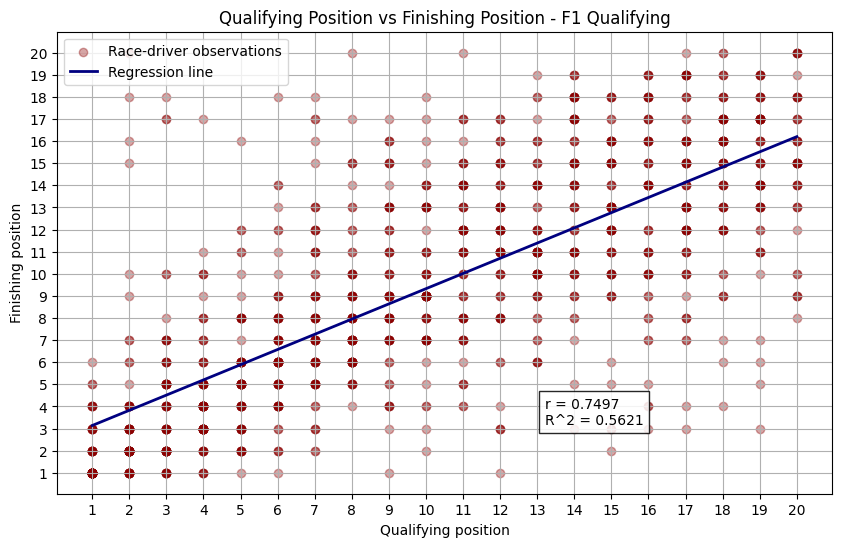

In [22]:
display(Image(filename=f"{RESULTS_DIR}/F1_Qualifying_scatterplot.png"))

## Average finishing position by grid position

This line chart summarizes the average finishing position for each grid slot. The pattern rises steadily, which supports the idea that qualifying position is a meaningful predictor of race outcome.

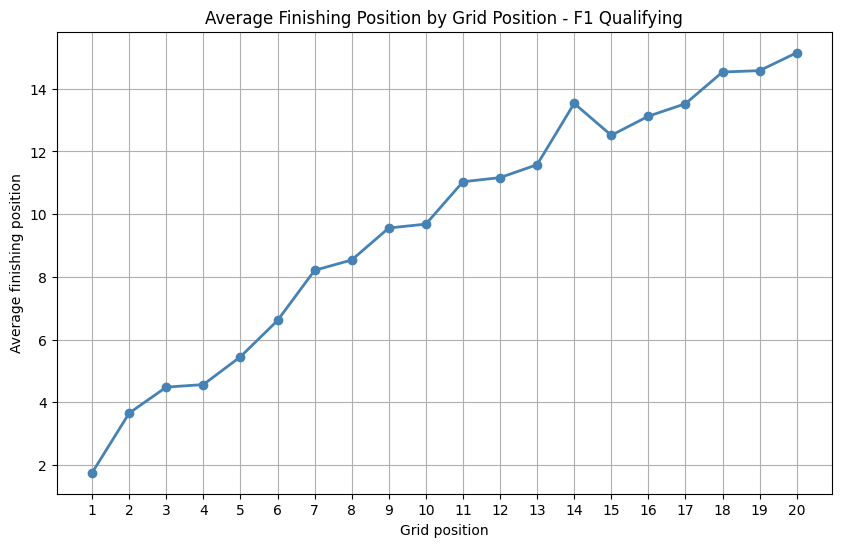

In [23]:
display(Image(filename=f"{RESULTS_DIR}/F1_Qualifying_linechart.png"))

## Pole position conversion to wins

This bar chart compares win rates for the first three grid positions. Pole position clearly has the strongest conversion rate, which matches the project question about how much starting order matters.

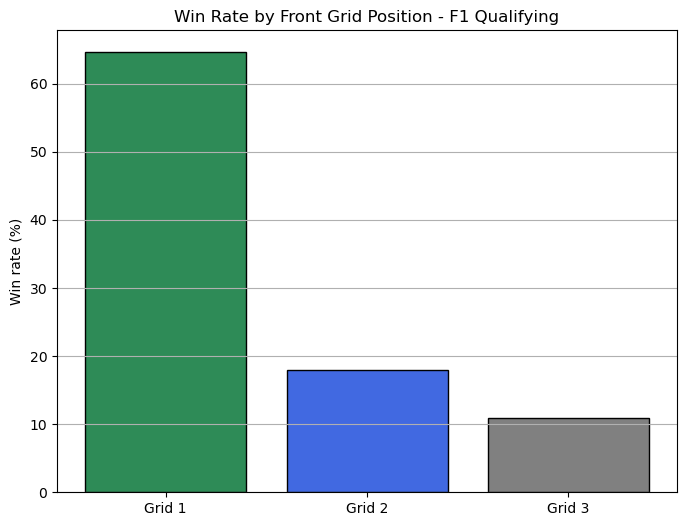

In [16]:
display(Image(filename=f"{RESULTS_DIR}/F1_Pole_to_Win_barchart.png"))

## Prediction performance

This predicted-versus-actual plot shows how the regression model performs across the full range of finishing positions. Points close to the diagonal line indicate more accurate predictions.

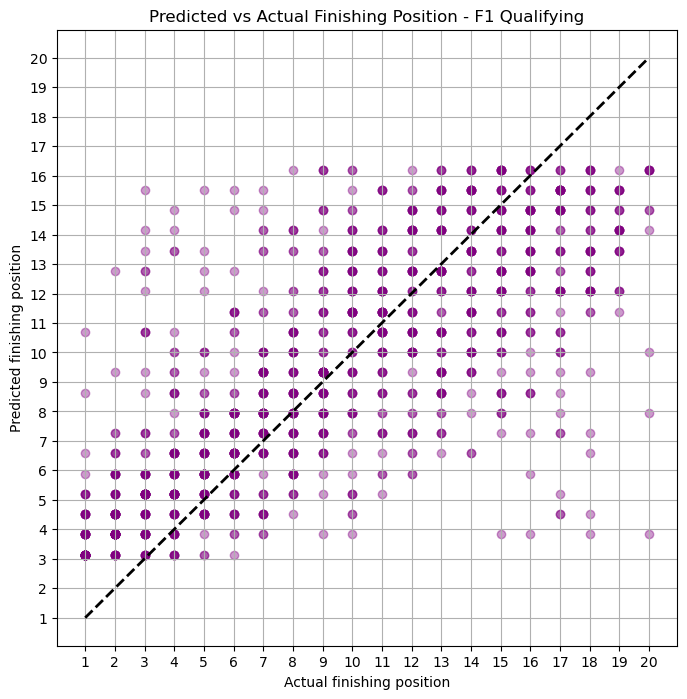

In [17]:
display(Image(filename=f"{RESULTS_DIR}/F1_Predicted_vs_Actual_scatterplot.png"))

## Variability by grid position

The boxplot adds uncertainty information that is not visible in averages alone. Even though front-grid starters usually finish better, the spread shows that race incidents, strategy, and overtaking still matter.

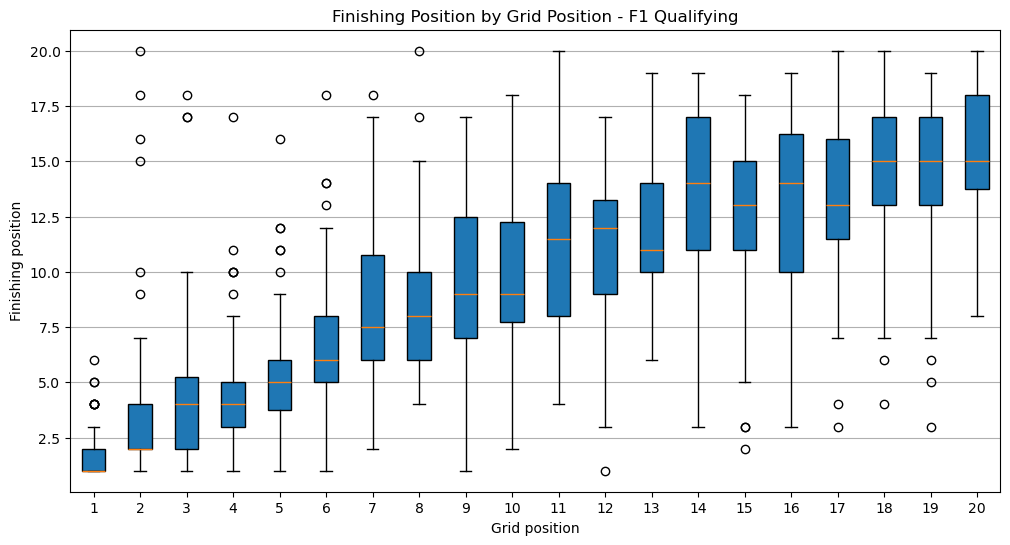

In [18]:
display(Image(filename=f"{RESULTS_DIR}/F1_Finishing_Position_boxplot.png"))

The saved output files appear in the `results/` folder, and the merged race table is stored in the `data/` folder.